In [11]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image
from scipy.stats import ttest_ind

In [2]:



df_images_Pannuke= pd.read_csv("df_images_Pannuke.csv")
df_nuclei_Pannuke = pd.read_csv("df_nuclei_Pannuke.csv")
df_dataset_Pannuke = pd.read_csv("df_dataset_Pannuke.csv")

df_images_Nuinsseg= pd.read_csv("df_images_Nuinsseg.csv")
df_nuclei_Nuinsseg= pd.read_csv("df_nuclei_Nuinsseg.csv")
df_dataset_Nuinsseg= pd.read_csv("df_dataset_Nuinsseg.csv")

In [7]:
# CONTROLLO SE LE IMMAGINI DI PANNUKE SONO 256 256
DATA_PATH_PANNUKE = 'data/raw/pannuke'

image_paths_pannuke = (
    glob.glob(os.path.join(DATA_PATH_PANNUKE, "train", "images", "*.png")) +
    glob.glob(os.path.join(DATA_PATH_PANNUKE, "validate", "images", "*.png"))
)


sizes_Pannuke = set()

for img_path in image_paths_pannuke:
    img = Image.open(img_path)
    sizes_Pannuke.add(img.size)

print(f"Trovate {len(image_paths_pannuke)} immagini")
print("Dimensioni uniche presenti nel dataset:", sizes_Pannuke)


Trovate 7901 immagini
Dimensioni uniche presenti nel dataset: {(256, 256)}


In [8]:
# CONTROLLO SE LE IMMAGINI DI NUINSSEG SONO 256 256: FALSO SONO 512 512
DATA_PATH_NUINSSEG = 'data/raw/nuinsseg'

folders = [
    "human bladder",
    "human brain",
    "human cardia",
    "human cerebellum",
    "human epiglottis",
    "human jejunum",
    "human kidney",
    "human liver",
    "human lung",
    "human melanoma",
    "human muscle",
    "human oesophagus",
    "human pancreas",
    "human peritoneum",
    "human placenta",
    "human pylorus",
    "human rectum",
    "human salivory gland",
    "human spleen",
    "human testis",
    "human tounge",
    "human tonsile",
    "human umbilical cord",
]

image_paths_nuinsseg = []
for folder in folders:
    image_paths_nuinsseg += glob.glob(os.path.join(DATA_PATH_NUINSSEG, folder, "tissue images", "*.png*"))

sizes_nuinsseg = set()

for img_path in image_paths_nuinsseg:
    img = Image.open(img_path)
    sizes_nuinsseg.add(img.size)

print(f"Trovate {len(image_paths_nuinsseg)} immagini")
print("Dimensioni uniche presenti nel dataset:", sizes_nuinsseg)

Trovate 432 immagini
Dimensioni uniche presenti nel dataset: {(512, 512)}


In [9]:
# CONFRONTO NUMERICO MDENSITà MEDIA
df_Pannuke = pd.read_csv("df_dataset_Pannuke.csv")
df_Nuinsseg = pd.read_csv("df_dataset_Nuinsseg.csv")

print("Densità media nuclei Pannuke:", df_Pannuke["mean_density"].mean())
print("Densità media nuclei Nuinsseg:", df_Nuinsseg["mean_density"].mean())

Densità media nuclei Pannuke: 0.0003105504439459
Densità media nuclei Nuinsseg: 0.0001754937348542


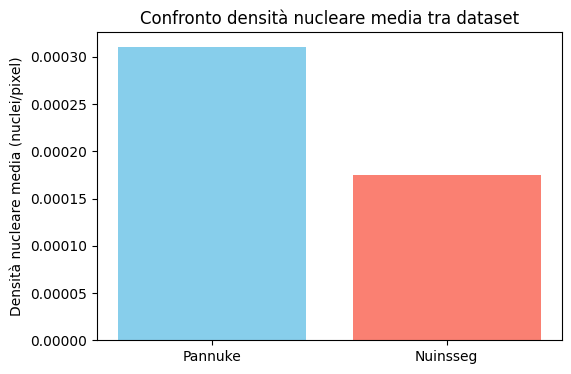

In [10]:
# CONFRONTO VIA VISIVA DENSITà MEDIA

import matplotlib.pyplot as plt

densities = [df_Pannuke["mean_density"].mean(), df_Nuinsseg["mean_density"].mean()]
datasets = ["Pannuke", "Nuinsseg"]

plt.figure(figsize=(6,4))
plt.bar(datasets, densities, color=["skyblue", "salmon"])
plt.ylabel("Densità nucleare media (nuclei/pixel)")
plt.title("Confronto densità nucleare media tra dataset")
plt.show()

In [12]:
# P_TEST

df_images_Pannuke = pd.read_csv("df_images_Pannuke.csv")
df_images_Nuinsseg = pd.read_csv("df_images_Nuinsseg.csv")


dens_Pannuke = df_images_Pannuke["density"].values
dens_Nuinsseg = df_images_Nuinsseg["density"].values

# T-test indipendente
t_stat, p_value = ttest_ind(dens_Pannuke, dens_Nuinsseg, equal_var=False)  # Welch's t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("La differenza di densità nucleare media è statisticamente significativa.")
else:
    print("La differenza di densità nucleare media NON è statisticamente significativa.")

T-statistic: 21.4413
P-value: 4.9077e-77
La differenza di densità nucleare media è statisticamente significativa.


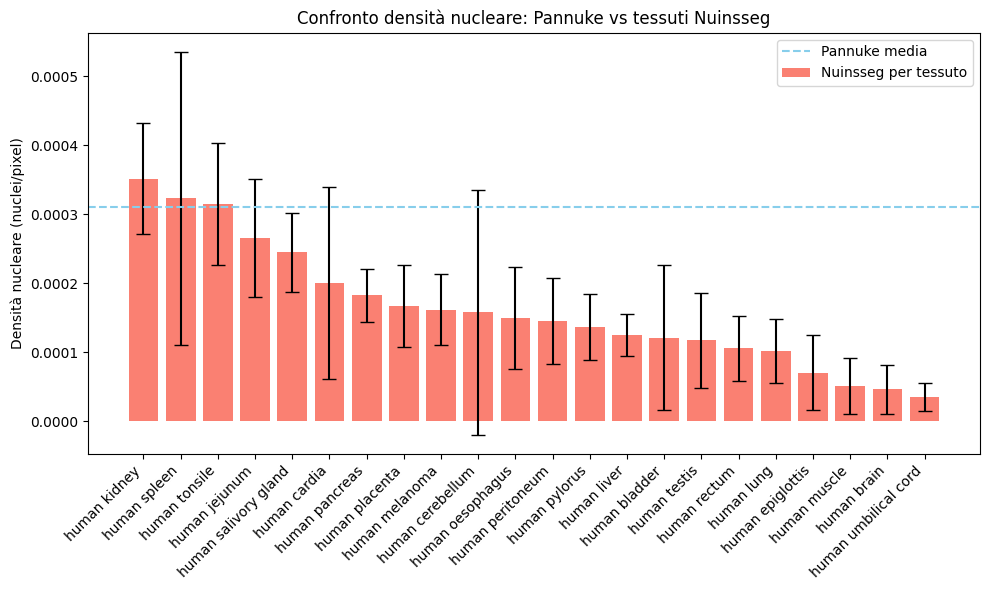

In [13]:
# CONFRONTO NELLO SPECIFICO CON TESSUTI NUINSSEG SPECIFICI

df_Pannuke = pd.read_csv("df_dataset_Pannuke.csv")
df_Nuinsseg = pd.read_csv("df_tissue_summary_Nuinsseg.csv")


dens_Pannuke = df_Pannuke["mean_density"].mean()

plt.figure(figsize=(10,6))

# barre per Nuinsseg (per tessuto)
plt.bar(df_Nuinsseg["Tissue"], df_Nuinsseg["MeanDensity"], yerr=df_Nuinsseg["StdDensity"],
        capsize=5, color="salmon", label="Nuinsseg per tessuto")

# linea orizzontale per Pannuke
plt.axhline(dens_Pannuke, color="skyblue", linestyle="--", label="Pannuke media")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Densità nucleare (nuclei/pixel)")
plt.title("Confronto densità nucleare: Pannuke vs tessuti Nuinsseg")
plt.legend()
plt.tight_layout()
plt.show()

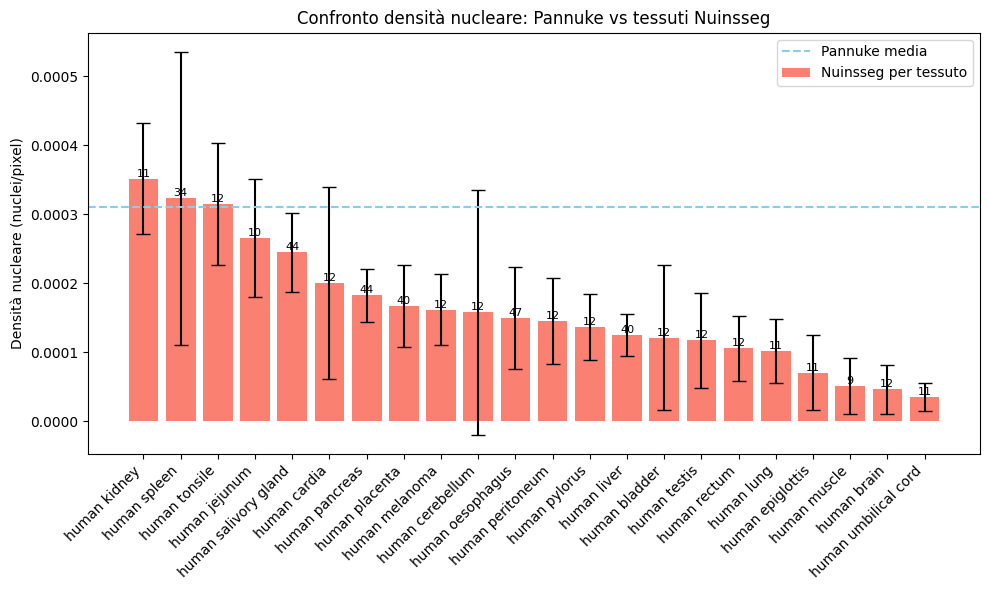

In [15]:
plt.figure(figsize=(10,6))
bars = plt.bar(df_Nuinsseg["Tissue"], df_Nuinsseg["MeanDensity"], yerr=df_Nuinsseg["StdDensity"],
        capsize=5, color="salmon", label="Nuinsseg per tessuto")

# ho aggiunto i numeri ma non si vedono
for bar, n in zip(bars, df_Nuinsseg["N_images"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(n),
             ha='center', va='bottom', fontsize=8)

plt.axhline(dens_Pannuke, color="skyblue", linestyle="--", label="Pannuke media")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Densità nucleare (nuclei/pixel)")
plt.title("Confronto densità nucleare: Pannuke vs tessuti Nuinsseg")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# CONFRONTO NUMERICO GLOBALE PANNUKE VS NUINSSEG

import pandas as pd

# Leggi i CSV
df_Pannuke = pd.read_csv("df_dataset_Pannuke.csv")
df_Nuinsseg = pd.read_csv("df_dataset_Nuinsseg.csv")

# RGB medi globali
rgb_Pannuke = df_Pannuke[["R_mean_dataset", "G_mean_dataset", "B_mean_dataset"]].mean()
rgb_Nuinsseg = df_Nuinsseg[["R_mean_dataset", "G_mean_dataset", "B_mean_dataset"]].mean()

print("RGB medi Pannuke:\n", rgb_Pannuke)
print("\nRGB medi Nuinsseg:\n", rgb_Nuinsseg)

RGB medi Pannuke:
 R_mean_dataset    179.722442
G_mean_dataset    146.195556
B_mean_dataset    189.045794
dtype: float64

RGB medi Nuinsseg:
 R_mean_dataset    110.199520
G_mean_dataset     70.895409
B_mean_dataset    100.308029
dtype: float64


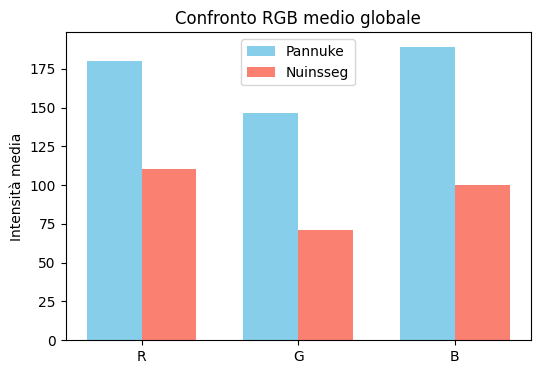

In [17]:
# CONFRONTO NUMERICO GLOBALE PANNUKE VS NUINSSEG


labels = ['R', 'G', 'B']
Pannuke_vals = rgb_Pannuke.values
Nuinsseg_vals = rgb_Nuinsseg.values

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, Pannuke_vals, width, label='Pannuke', color='skyblue')
plt.bar(x + width/2, Nuinsseg_vals, width, label='Nuinsseg', color='salmon')
plt.xticks(x, labels)
plt.ylabel('Intensità media')
plt.title('Confronto RGB medio globale')
plt.legend()
plt.show()